In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline 

In [5]:
df = pd.read_csv(r'D:\ML+PHYTHON\machine learning\UNSUPERVISED learning\k means clustering\using dataset\Instagram visits clustering.csv')

In [6]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [8]:
X = df.iloc[:, 1:3]

print(X.head())

   Instagram visit score  Spending_rank(0 to 100)
0                     63                24.050708
1                     61                25.223290
2                    104                18.528245
3                     82                86.890232
4                     14                31.492397


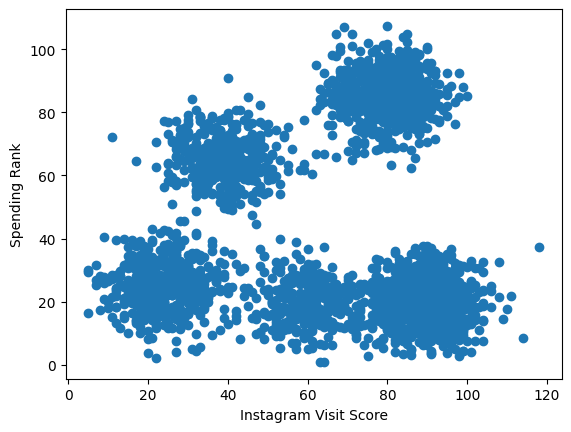

In [9]:
import matplotlib.pyplot as plt

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1]
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")

plt.show()

In [14]:
from sklearn.cluster import KMeans

wcss= []

for k in range(1,11):
    model=KMeans(n_clusters=k,init='k-means++')
    model.fit_predict(X)
    wcss.append(model.inertia_)



In [15]:
wcss

[3985634.779671739,
 2079628.0206598141,
 847029.7762594037,
 673117.8048116344,
 278407.5245719686,
 251465.3790610419,
 235196.79268720938,
 215341.79279138116,
 189608.11638685333,
 174788.24423134682]

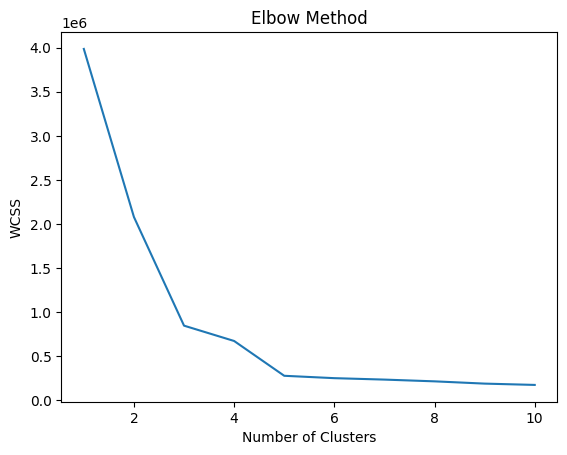

In [16]:
plt.plot(range(1,11), wcss)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [34]:
finalmodel=KMeans(n_clusters=3,init='k-means++')

labels= finalmodel.fit_predict(X)

In [37]:
df['clusters']=labels
df.head(5)

,User ID,Instagram visit score,Spending_rank(0 to 100),clusters
0,0,63,24.050708,0
1,1,61,25.223290,0
2,2,104,18.528245,0
3,3,82,86.890232,1
4,4,14,31.492397,2


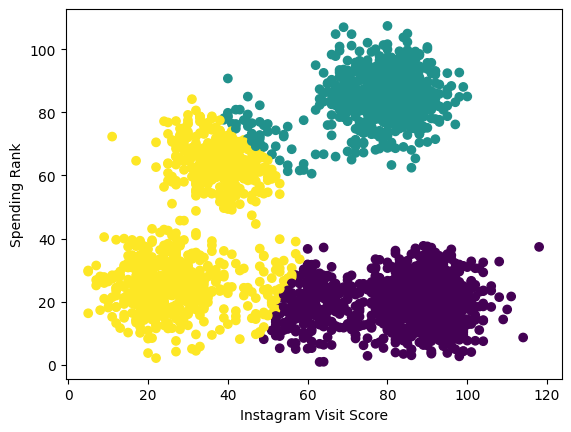

In [35]:
plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=labels
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")

plt.show()

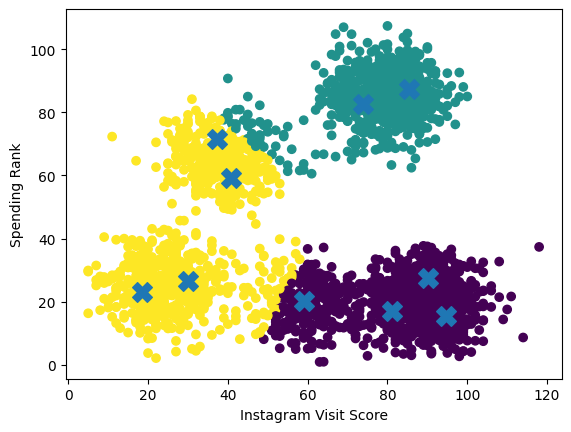

In [36]:
plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=labels
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    s=200,
    marker="X"
)

plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")

plt.show()

FINDING K BY FUNCTION 

In [25]:
from kneed import KneeLocator

kl=KneeLocator(range(1,11), wcss , curve='convex', direction='decreasing')# convex is used when the value is decreasing
kl.elbow

np.int64(3)